In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage, SystemMessage,BaseMessage
from langgraph.graph.message import add_messages
import operator
from langgraph.checkpoint.memory import MemorySaver #saves in RAM memory
load_dotenv(dotenv_path='F:\\agentic_ai\\AgenticAIWorkspace\\.env')

f:\agentic_ai\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage,BaseMessage
from langgraph.graph.message import add_messages
import operator
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv(dotenv_path='F:\\agentic_ai\\AgenticAIWorkspace\\.env')

True

In [3]:
llm = ChatOpenAI()

In [4]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [5]:
def generate_joke(state:JokeState):

    prompt=f"""
    Generate a joke on topic {state['topic']}
    """
    response = llm.invoke(prompt).content

    return {'joke':response}


In [6]:
def generate_explanation(state:JokeState):

    prompt = f""" 
    Write an explanation for the joke: {state['joke']}
    """
    response = llm.invoke(prompt).content

    return {'explanation': response}

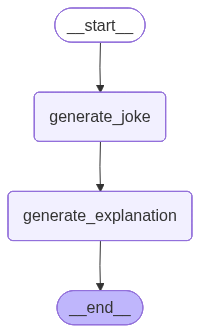

In [7]:
graph = StateGraph(JokeState)

# add node
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

#add edge
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [8]:
config1 = {'configurable':{"thread_id":'1'}}
workflow.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!',
 'explanation': 'This joke is a play on words. The phrase "get to the crust of the issue" is a common saying that means to get to the root or main cause of a problem. In this joke, the pizza going to a therapist is portrayed as a person seeking therapy to uncover and address its underlying issues, represented by its crust. The humor comes from the fact that a pizza, typically seen as an inanimate object, is anthropomorphized and portrayed as having emotional or psychological issues that require therapy.'}

In [9]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!', 'explanation': 'This joke is a play on words. The phrase "get to the crust of the issue" is a common saying that means to get to the root or main cause of a problem. In this joke, the pizza going to a therapist is portrayed as a person seeking therapy to uncover and address its underlying issues, represented by its crust. The humor comes from the fact that a pizza, typically seen as an inanimate object, is anthropomorphized and portrayed as having emotional or psychological issues that require therapy.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-6b45-6292-8002-0efba820d29b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-22T15:41:34.370472+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-522c-60b6-800

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!', 'explanation': 'This joke is a play on words. The phrase "get to the crust of the issue" is a common saying that means to get to the root or main cause of a problem. In this joke, the pizza going to a therapist is portrayed as a person seeking therapy to uncover and address its underlying issues, represented by its crust. The humor comes from the fact that a pizza, typically seen as an inanimate object, is anthropomorphized and portrayed as having emotional or psychological issues that require therapy.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-6b45-6292-8002-0efba820d29b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-22T15:41:34.370472+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-522c-60b6-80

In [11]:
config2 = {'configurable':{'thread_id':'2'}}
workflow.invoke({'topic':'pasta'},config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta go to the party? \nBecause it heard it was going to be a penne-tastic time!',
 'explanation': 'This joke is a play on words, combining the word "penne" (a type of pasta) with the phrase "fantastic time." The pasta went to the party because it heard it was going to be a "penne-tastic" time, meaning it was going to be a very enjoyable and fun experience. The humor comes from the clever wordplay and pun of combining the pasta name with a positive adjective.'}

## Time Travel

In [12]:
workflow.get_state({'configurable':{'thread_id':'1'}})  

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!', 'explanation': 'This joke is a play on words. The phrase "get to the crust of the issue" is a common saying that means to get to the root or main cause of a problem. In this joke, the pizza going to a therapist is portrayed as a person seeking therapy to uncover and address its underlying issues, represented by its crust. The humor comes from the fact that a pizza, typically seen as an inanimate object, is anthropomorphized and portrayed as having emotional or psychological issues that require therapy.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-6b45-6292-8002-0efba820d29b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-22T15:41:34.370472+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-522c-60b6-800

In [ ]:
list(workflow.get_state_history({'configurable':{'thread_id':'1'}}))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!', 'explanation': 'This joke is a play on words. The phrase "get to the crust of the issue" is a common saying that means to get to the root or main cause of a problem. In this joke, the pizza going to a therapist is portrayed as a person seeking therapy to uncover and address its underlying issues, represented by its crust. The humor comes from the fact that a pizza, typically seen as an inanimate object, is anthropomorphized and portrayed as having emotional or psychological issues that require therapy.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-6b45-6292-8002-0efba820d29b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-22T15:41:34.370472+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-522c-60b6-80

In [16]:
workflow.invoke(None,{'configurable':{'thread_id':'1'},'checkpoint_id': '1f0af5d9-37bb-6a4a-8000-781489aecff6'})

{'topic': 'pizza',
 'joke': 'Why did the pizza maker go to therapy?\nBecause he kneaded some dough to work through his emotional crust issues!',
 'explanation': 'This joke plays on the word "kneaded," which is a term used in baking to describe the process of working and shaping dough through kneading. In this case, the joke suggests that the pizza maker went to therapy not to seek help for traditional emotional issues, but because he needed to work through his "emotional crust issues" – a pun on the idea of emotional stress or problems being related to his job of making pizza crust. The humor comes from the unexpected twist on the word "kneaded" and the clever wordplay involved in the punchline.'}

In [18]:
workflow.update_state({'configurable':{'thread_id':'1'},'checkpoint_id': '1f0af5d9-37bb-6a4a-8000-781489aecff6','checkpoint_ns':""},{'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0af5f1-4f59-613d-8001-4cd027a57646'}}

In [19]:
list(workflow.get_state_history({'configurable':{'thread_id':'1'}}))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5f1-4f59-613d-8001-4cd027a57646'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-10-22T15:52:15.687711+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0af5d9-37bb-6a4a-8000-781489aecff6'}}, tasks=(PregelTask(id='55beeb3b-86c7-d1db-9fad-1d34512aba0b', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker go to therapy?\nBecause he kneaded some dough to work through his emotional crust issues!', 'explanation': 'This joke plays on the word "kneaded," which is a term used in baking to 

In [20]:
workflow.invoke(None,{'configurable':{'thread_id':'1'},'checkpoint_id': '1f0af5f1-4f59-613d-8001-4cd027a57646'})

{'topic': 'samosa',
 'joke': 'Why did the pizza go to the therapist?\nBecause it wanted to get to the crust of its issues!',
 'explanation': 'This joke is a play on words, as "crust" can refer to the outer edge of a pizza as well as to deep-seated emotional or psychological issues. By saying the pizza went to the therapist to "get to the crust of its issues," it is suggesting that the pizza went to therapy to address its underlying problems and work through them. The joke combines a pun with a humorous concept of a pizza having its own emotional struggles, making it a light-hearted and humorous play on words.'}